In [7]:
import matplotlib.pyplot as plt
import librosa
import numpy as np
import scipy.signal
# Fix for the "hann" attribute error
if not hasattr(scipy.signal, 'hann'):
    scipy.signal.hann = scipy.signal.windows.hann

In [8]:
def save_debug_plot_stems(vocal_path, bass_path, drums_path, other_path, mashup_path, output_img="debug_viz_stems.png"):
    print("Loading audio files...")
    # Load all stems with the same sample rate
    y_voc, sr = librosa.load(vocal_path)
    y_bass, _ = librosa.load(bass_path, sr=sr)
    y_drums, _ = librosa.load(drums_path, sr=sr)
    y_other, _ = librosa.load(other_path, sr=sr)
    
    # 1. Create the Full Instrumental (Sum of stems)
    # We crop to the minimum length to avoid shape errors
    min_len = min(len(y_bass), len(y_drums), len(y_other), len(y_voc))
    y_bass = y_bass[:min_len]
    y_drums = y_drums[:min_len]
    y_other = y_other[:min_len]
    y_voc = y_voc[:min_len]
    
    # Mix them for the silence check
    y_inst_full = y_bass + y_drums + y_other

    # 2. Envelope (Volume) Analysis for Gaps
    hop_length = 512
    rms_voc = librosa.feature.rms(y=y_voc, hop_length=hop_length)[0]
    rms_inst = librosa.feature.rms(y=y_inst_full, hop_length=hop_length)[0]
    times = librosa.frames_to_time(range(len(rms_voc)), sr=sr, hop_length=hop_length)

    # 3. Beat Analysis (USING ONLY DRUMS for accuracy)
    print("Analyzing beats on Drum track...")
    onset_env_drums = librosa.onset.onset_strength(y=y_drums, sr=sr)
    beats_drums = librosa.beat.beat_track(onset_envelope=onset_env_drums, sr=sr)[1]
    beat_times = librosa.frames_to_time(beats_drums, sr=sr)

    # --- PLOTTING ---
    plt.figure(figsize=(12, 12))

    # Plot A: Structure & Gaps (Uses Full Instrumental)
    plt.subplot(3, 1, 1)
    plt.title("Structure Check: Look for Silences (Instrumental vs Vocal)")
    plt.plot(times, rms_inst, label='Full Instrumental', color='blue', alpha=0.6)
    plt.plot(times, rms_voc, label='Vocal', color='orange', alpha=0.6)
    
    # Highlight danger zones
    danger_zone = (rms_inst < 0.01) & (rms_voc > 0.05)
    plt.fill_between(times, 0, np.max(rms_voc), where=danger_zone, color='red', alpha=0.3, label='BUG: Silence')
    plt.legend(loc='upper right')

    # Plot B: Alignment Check (Vocals vs DRUMS)
    plt.subplot(3, 1, 2)
    plt.title("Alignment Check: Do Vocal peaks align with Drum hits?")
    
    # Zoom into a specific window (e.g., 30s to 40s)
    start_time = 30
    end_time = 40
    start_sample = int(sr * start_time)
    end_sample = int(sr * end_time)
    
    # Check if song is long enough
    if len(y_voc) > end_sample:
        time_axis = np.linspace(start_time, end_time, end_sample-start_sample)
        plt.plot(time_axis, y_voc[start_sample:end_sample], alpha=0.8, label='Vocal Wave', color='orange')
        plt.plot(time_axis, y_drums[start_sample:end_sample], alpha=0.4, label='Drum Wave', color='blue')
        
        # Filter beats within this window
        local_beats = [b for b in beat_times if start_time < b < end_time]
        plt.vlines(local_beats, -1, 1, color='red', linestyle='--', linewidth=2, label='Drum Beat (Ref)')
        plt.legend(loc='upper right')
    else:
        plt.text(0.5, 0.5, "Song too short for 30s zoom", ha='center')

    # Plot C: Quality Check (Spectrogram of Final Mashup)
    plt.subplot(3, 1, 3)
    plt.title("Quality Check: Spectrogram of Final Mashup")
    try:
        y_mash, _ = librosa.load(mashup_path, sr=sr)
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y_mash)), ref=np.max)
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
        plt.colorbar(format='%+2.0f dB')
    except Exception as e:
        plt.text(0.5, 0.5, f"Could not load mashup: {e}", ha='center')

    plt.tight_layout()
    plt.savefig(output_img)
    print(f"Debug image saved to {output_img}")



Loading audio files...
Analyzing beats on Drum track...
Debug image saved to debug_viz_stems.png


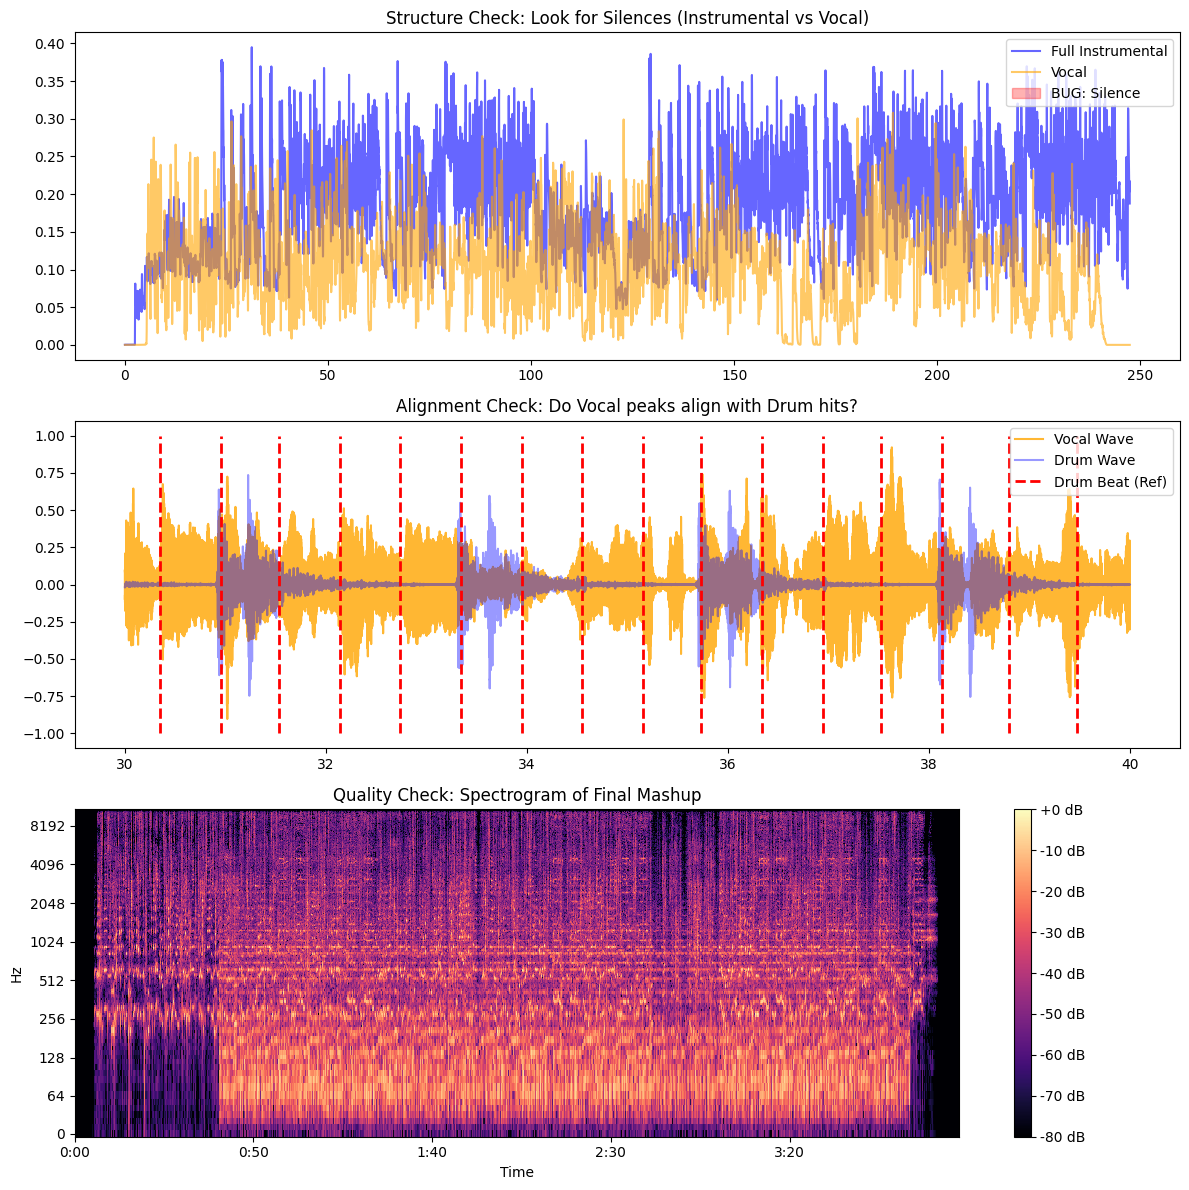

In [9]:
# Define paths here
v_path = "automashup/automashup/data/separated/htdemucs/M7_lyrics/vocals.wav"
b_path = "automashup/automashup/data/separated/htdemucs/M7_instru/bass.wav"
d_path = "automashup/automashup/data/separated/htdemucs/M7_instru/drums.wav"
o_path = "automashup/automashup/data/separated/htdemucs/M7_instru/other.wav"
m_path = "automashup/mashup_7_enhanced.mp3"

save_debug_plot_stems(v_path, b_path, d_path, o_path, m_path)